In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [81]:
train_df=pd.read_excel("Data_Train.xlsx")
train_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [82]:
test_df=pd.read_excel("Test_set.xlsx")
test_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [83]:
final_df=pd.concat([train_df,test_df], ignore_index=True)
final_df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
13349,Air India,6/06/2019,Kolkata,Banglore,CCU → DEL → BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info,NaN
13350,IndiGo,27/03/2019,Kolkata,Banglore,CCU → BLR,14:20,16:55,2h 35m,non-stop,No info,NaN
13351,Jet Airways,6/03/2019,Delhi,Cochin,DEL → BOM → COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info,NaN
13352,Air India,6/03/2019,Delhi,Cochin,DEL → BOM → COK,04:00,19:15,15h 15m,1 stop,No info,NaN
13353,Multiple carriers,15/06/2019,Delhi,Cochin,DEL → BOM → COK,04:55,19:15,14h 20m,1 stop,No info,NaN


In [84]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Date_of_Journey  13354 non-null  object 
 2   Source           13354 non-null  object 
 3   Destination      13354 non-null  object 
 4   Route            13353 non-null  object 
 5   Dep_Time         13354 non-null  object 
 6   Arrival_Time     13354 non-null  object 
 7   Duration         13354 non-null  object 
 8   Total_Stops      13353 non-null  object 
 9   Additional_Info  13354 non-null  object 
 10  Price            10683 non-null  float64
dtypes: float64(1), object(10)
memory usage: 1.1+ MB


In [85]:
final_df['Date']=final_df['Date_of_Journey'].str.split('/').str[0]
final_df['Month']=final_df['Date_of_Journey'].str.split('/').str[1]
final_df['Year']=final_df['Date_of_Journey'].str.split('/').str[2]

# ---------------------------
# Alternate Method
# ---------------------------

# df["Date"]=df['Date_of_Journey'].apply(lambda x:x.split("/")[0])
# df["Month"]=df['Date_of_Journey'].apply(lambda x:x.split("/")[1])
# df["Year"]=df['Date_of_Journey'].apply(lambda x:x.split("/")[2])

In [86]:
final_df.drop('Date_of_Journey', axis=1, inplace=True)
final_df.head(2)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,03,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,05,2019


In [87]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Dep_Time         13354 non-null  object 
 5   Arrival_Time     13354 non-null  object 
 6   Duration         13354 non-null  object 
 7   Total_Stops      13353 non-null  object 
 8   Additional_Info  13354 non-null  object 
 9   Price            10683 non-null  float64
 10  Date             13354 non-null  object 
 11  Month            13354 non-null  object 
 12  Year             13354 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.3+ MB


In [88]:
final_df['Date']=final_df['Date'].astype(int)
final_df['Month']=final_df['Month'].astype(int)
final_df['Year']=final_df['Year'].astype(int)

In [89]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Dep_Time         13354 non-null  object 
 5   Arrival_Time     13354 non-null  object 
 6   Duration         13354 non-null  object 
 7   Total_Stops      13353 non-null  object 
 8   Additional_Info  13354 non-null  object 
 9   Price            10683 non-null  float64
 10  Date             13354 non-null  int32  
 11  Month            13354 non-null  int32  
 12  Year             13354 non-null  int32  
dtypes: float64(1), int32(3), object(9)
memory usage: 1.2+ MB


In [90]:
final_df['Arrival_Time']=final_df['Arrival_Time'].str.split(' ').str[0]

# final_df['Arrival_Time']=final_df['Arrival_Time'].apply(lambda x : x.split(' ')[0])

In [91]:
final_df['Arrival_Hour']=final_df['Arrival_Time'].str.split(':').str[0].astype(int)
final_df['Arrival_Minute']=final_df['Arrival_Time'].str.split(':').str[-1].astype(int)

In [93]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Dep_Time         13354 non-null  object 
 5   Arrival_Time     13354 non-null  object 
 6   Duration         13354 non-null  object 
 7   Total_Stops      13353 non-null  object 
 8   Additional_Info  13354 non-null  object 
 9   Price            10683 non-null  float64
 10  Date             13354 non-null  int32  
 11  Month            13354 non-null  int32  
 12  Year             13354 non-null  int32  
 13  Arrival_Hour     13354 non-null  int32  
 14  Arrival_Minute   13354 non-null  int32  
dtypes: float64(1), int32(5), object(9)
memory usage: 1.3+ MB


In [94]:
final_df.drop('Arrival_Time',axis=1,inplace=True)
final_df.head()

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897.0,24,3,2019,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662.0,1,5,2019,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,19h,2 stops,No info,13882.0,9,6,2019,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,5h 25m,1 stop,No info,6218.0,12,5,2019,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,4h 45m,1 stop,No info,13302.0,1,3,2019,21,35


In [95]:
final_df['Dep_Time'].str.split(':').str[0]

0        22
1        05
2        09
3        18
4        16
         ..
13349    20
13350    14
13351    21
13352    04
13353    04
Name: Dep_Time, Length: 13354, dtype: object

In [96]:
final_df['Dep_Time'].str.split(':').str[-1]

0        20
1        50
2        25
3        05
4        50
         ..
13349    30
13350    20
13351    50
13352    00
13353    55
Name: Dep_Time, Length: 13354, dtype: object

In [97]:
final_df['Dep_Hour']=final_df['Dep_Time'].str.split(':').str[0]
final_df['Dep_Minute']=final_df['Dep_Time'].str.split(':').str[-1]
final_df['Dep_Hour']=final_df['Dep_Hour'].astype(int)
final_df['Dep_Minute']=final_df['Dep_Minute'].astype(int)
final_df.drop('Dep_Time',axis=1,inplace=True)
final_df.head(2)



,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897.0,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662.0,1,5,2019,13,15,5,50


In [98]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Duration         13354 non-null  object 
 5   Total_Stops      13353 non-null  object 
 6   Additional_Info  13354 non-null  object 
 7   Price            10683 non-null  float64
 8   Date             13354 non-null  int32  
 9   Month            13354 non-null  int32  
 10  Year             13354 non-null  int32  
 11  Arrival_Hour     13354 non-null  int32  
 12  Arrival_Minute   13354 non-null  int32  
 13  Dep_Hour         13354 non-null  int32  
 14  Dep_Minute       13354 non-null  int32  
dtypes: float64(1), int32(7), object(7)
memory usage: 1.2+ MB


In [99]:
final_df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [100]:
final_df.isnull().sum()

Airline               0
Source                0
Destination           0
Route                 1
Duration              0
Total_Stops           1
Additional_Info       0
Price              2671
Date                  0
Month                 0
Year                  0
Arrival_Hour          0
Arrival_Minute        0
Dep_Hour              0
Dep_Minute            0
dtype: int64

In [101]:
final_df['Total_Stops'].fillna(final_df['Total_Stops'].mode()[0],inplace=True)
final_df['Total_Stops']=final_df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4})

In [102]:
final_df.isnull().sum()

Airline               0
Source                0
Destination           0
Route                 1
Duration              0
Total_Stops           0
Additional_Info       0
Price              2671
Date                  0
Month                 0
Year                  0
Arrival_Hour          0
Arrival_Minute        0
Dep_Hour              0
Dep_Minute            0
dtype: int64

Observation: Total_Stops ka null fill ho gaya mode se. Route mein 1 null hai jo baad mein drop ho jayega (Route column hi drop kar rahe hain). Price mein 2671 nulls hain kyunki ye test data hai jahan price nahi diya gaya - ye expected hai.

Observation: Total_Stops ka null fill ho gaya mode se. Route mein 1 null hai jo baad mein drop ho jayega (Route column hi drop kar rahe hain). Price mein 2671 nulls hain kyunki ye test data hai jahan price nahi diya gaya - ye expected hai.

In [103]:
final_df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,0,No info,3897.0,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662.0,1,5,2019,13,15,5,50


In [104]:
final_df.drop('Route', axis=1, inplace=True)

In [105]:
final_df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897.0,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662.0,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,19h,2,No info,13882.0,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,5h 25m,1,No info,6218.0,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,4h 45m,1,No info,13302.0,1,3,2019,21,35,16,50


In [106]:
final_df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [107]:
final_df['duration_hour']=final_df['Duration'].str.split(' ').str[0].str.split('h').str[0]
final_df['duration_minute']=final_df['Duration'].str.split(' ').str[-1].str.split('m').str[0]

In [108]:
final_df[final_df['duration_hour']=='5m']


,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,duration_hour,duration_minute
6474,Air India,Mumbai,Hyderabad,5m,2,No info,17327.0,6,3,2019,16,55,16,50,5m,5
13343,Air India,Mumbai,Hyderabad,5m,2,No info,NaN,12,3,2019,16,55,16,50,5m,5


In [109]:
final_df.drop(6474,axis=0,inplace=True)
final_df.drop(13343,axis=0,inplace=True)

In [110]:
final_df[final_df['duration_hour']=='5m']


,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,duration_hour,duration_minute


In [111]:
final_df['duration_hour'] = final_df['Duration'].str.extract(r'(\d+)h').fillna(0).astype(int)
final_df['duration_minute'] = final_df['Duration'].str.extract(r'(\d+)m').fillna(0).astype(int)

In [112]:
final_df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,duration_hour,duration_minute
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897.0,24,3,2019,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662.0,1,5,2019,13,15,5,50,7,25
2,Jet Airways,Delhi,Cochin,19h,2,No info,13882.0,9,6,2019,4,25,9,25,19,0
3,IndiGo,Kolkata,Banglore,5h 25m,1,No info,6218.0,12,5,2019,23,30,18,5,5,25
4,IndiGo,Banglore,New Delhi,4h 45m,1,No info,13302.0,1,3,2019,21,35,16,50,4,45


In [113]:
final_df.drop('Duration',axis=1,inplace=True)
final_df.head(1)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,duration_hour,duration_minute
0,IndiGo,Banglore,New Delhi,0,No info,3897.0,24,3,2019,1,10,22,20,2,50


In [114]:
final_df['Total_Duration']=final_df['duration_hour']*60 + final_df['duration_minute']
final_df.head(2) 

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,duration_hour,duration_minute,Total_Duration
0,IndiGo,Banglore,New Delhi,0,No info,3897.0,24,3,2019,1,10,22,20,2,50,170
1,Air India,Kolkata,Banglore,2,No info,7662.0,1,5,2019,13,15,5,50,7,25,445


In [115]:
final_df.drop(['duration_hour','duration_minute'],axis=1,inplace=True)
final_df.head(3)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Total_Duration
0,IndiGo,Banglore,New Delhi,0,No info,3897.0,24,3,2019,1,10,22,20,170
1,Air India,Kolkata,Banglore,2,No info,7662.0,1,5,2019,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,2,No info,13882.0,9,6,2019,4,25,9,25,1140


In [116]:
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()

In [117]:

final_df['Airline']=labelencoder.fit_transform(final_df['Airline'])
final_df['Source']=labelencoder.fit_transform(final_df['Source'])
final_df['Destination']=labelencoder.fit_transform(final_df['Destination'])
final_df['Additional_Info']=labelencoder.fit_transform(final_df['Additional_Info'])

In [118]:
final_df.shape

(13352, 14)

In [119]:
final_df.head(2)


,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Total_Duration
0,3,0,5,0,8,3897.0,24,3,2019,1,10,22,20,170
1,1,3,0,2,8,7662.0,1,5,2019,13,15,5,50,445


In [120]:
pd.get_dummies(final_df,columns=["Airline", "Source", "Destination"] ,drop_first = True)
final_df.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Total_Duration
0,3,0,5,0,8,3897.0,24,3,2019,1,10,22,20,170
1,1,3,0,2,8,7662.0,1,5,2019,13,15,5,50,445


In [121]:
X=final_df.drop('Price',axis=1)
y=final_df['Price']

In [122]:
X

,Airline,Source,Destination,Total_Stops,Additional_Info,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Total_Duration
0,3,0,5,0,8,24,3,2019,1,10,22,20,170
1,1,3,0,2,8,1,5,2019,13,15,5,50,445
2,4,2,1,2,8,9,6,2019,4,25,9,25,1140
3,3,3,0,1,8,12,5,2019,23,30,18,5,325
4,3,0,5,1,8,1,3,2019,21,35,16,50,285
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13349,1,3,0,1,8,6,6,2019,20,25,20,30,1435
13350,3,3,0,0,8,27,3,2019,16,55,14,20,155
13351,4,2,1,1,8,6,3,2019,4,25,21,50,395
13352,1,2,1,1,8,6,3,2019,19,15,4,0,915


In [123]:
y

0         3897.0
1         7662.0
2        13882.0
3         6218.0
4        13302.0
          ...   
13349        NaN
13350        NaN
13351        NaN
13352        NaN
13353        NaN
Name: Price, Length: 13352, dtype: float64

In [124]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [125]:
from sklearn.ensemble import RandomForestRegressor
rfg=RandomForestRegressor()

mask = y_train.notna()
rfg.fit(X_train.loc[mask], y_train.loc[mask])

RandomForestRegressor()

In [126]:
y_pred=rfg.predict(X_test)
y_pred

array([ 5007.89,  7064.  ,  6986.1 , ..., 13885.03, 11107.93,  5610.9 ])

In [127]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

eval_mask = y_test.notna()
y_test_eval = y_test[eval_mask]
y_pred_eval = y_pred[eval_mask.values]

mae = mean_absolute_error(y_test_eval, y_pred_eval)
mse = mean_squared_error(y_test_eval, y_pred_eval)
r2 = r2_score(y_test_eval, y_pred_eval)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)
print("RMSE:", rmse)

MAE: 700.3330153936445
MSE: 3793998.870678776
R2 Score: 0.8267211484612642
RMSE: 1947.8190035726564


In [128]:
rfg.feature_importances_

array([0.13108795, 0.00843104, 0.04275249, 0.04415679, 0.0495334 ,
       0.10812675, 0.04749809, 0.        , 0.0275226 , 0.01953208,
       0.02672912, 0.02419173, 0.47043798])

In [129]:
feature_importance = pd.Series(
    rfg.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

Total_Duration     0.470438
Airline            0.131088
Date               0.108127
Additional_Info    0.049533
Month              0.047498
Total_Stops        0.044157
Destination        0.042752
Arrival_Hour       0.027523
Dep_Hour           0.026729
Dep_Minute         0.024192
Arrival_Minute     0.019532
Source             0.008431
Year               0.000000
dtype: float64


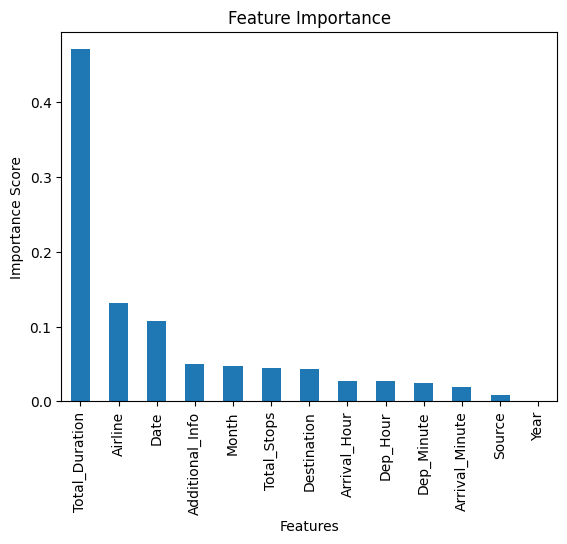

In [130]:
feature_importance.plot(kind='bar')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()


In [131]:
# X = X.drop(['Year'], axis=1)
# X = X.drop(['Source'], axis=1)


In [132]:
# X_temp = X.drop(['Total_Duration'], axis=1)

Observation: Yahan humne Duration_Hour, Duration_Min aur Dep_Time_Bucket add kiye hain. Isse model accuracy thodi aur badh gayi R2 Score 0.80 se 0.807 ho gaya.

Observation: When we removed the Year with '0' importance, it caused a lot of affect on the model and it's accuracy got reduced..

In [135]:
final_df['Duration_Hour'] = final_df['Total_Duration'] // 60
final_df['Duration_Min'] = final_df['Total_Duration'] % 60

In [136]:
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 0
    elif 12 <= hour < 17:
        return 1
    elif 17 <= hour < 21:
        return 2
    else:
        return 3

final_df['Dep_Time_Bucket'] = final_df['Dep_Hour'].apply(get_time_of_day)

In [138]:
# =====================================
# 1. IMPORTS
# =====================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================
# 2. FEATURE ENGINEERING (SIMPLE + SAFE)
# =====================================

# Duration split (recommended)
final_df['Duration_Hour'] = final_df['Total_Duration'] // 60
final_df['Duration_Min'] = final_df['Total_Duration'] % 60

# =====================================
# 3. DEFINE X & y
# =====================================
X = final_df.drop(['Price', 'Year'], axis=1)   # drop useless feature
y = final_df['Price']

# =====================================
# 4. TRAIN TEST SPLIT
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================
# 5. HANDLE NaN IN TARGET
# =====================================
mask = y_train.notna()
X_train = X_train.loc[mask]
y_train = y_train.loc[mask]

# =====================================
# 6. MODEL TRAINING
# =====================================
rfg = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

rfg.fit(X_train, y_train)

# =====================================
# 7. PREDICTION
# =====================================
y_pred = rfg.predict(X_test)

# =====================================
# 8. EVALUATION
# =====================================
eval_mask = y_test.notna()
y_test = y_test.loc[eval_mask]
y_pred = y_pred[eval_mask.values]

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# =====================================
# 9. FEATURE IMPORTANCE
# =====================================
feature_importance = pd.Series(
    rfg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:\n")
print(feature_importance)

MAE: 705.7753923046023
MSE: 4382370.968441135
RMSE: 2093.411323281007
R2 Score: 0.8070755481034103

Feature Importance:

Total_Duration     0.431390
Airline            0.131433
Date               0.100413
Additional_Info    0.061811
Month              0.045998
Total_Stops        0.044663
Destination        0.039957
Duration_Hour      0.035992
Arrival_Hour       0.023329
Dep_Hour           0.019854
Dep_Minute         0.019716
Arrival_Minute     0.016165
Duration_Min       0.014266
Source             0.008399
Dep_Time_Bucket    0.006614
dtype: float64
